# 第 11 章 · 冰湖导航价值迭代代码实验

本页把冰湖导航看成一个 MDP：每个格子是状态，每个方向是动作，滑倒会让转移带有不确定性。读者重点看价值如何从终点向外传播。

[章节网页](../ch11.html)

## 运行内容

- 读取 FrozenLake-v1 转移表
- 执行价值迭代
- 绘制价值与策略

## 0. 冰湖环境

先看地图和转移表。S 是起点，F 是安全冰面，H 是洞，G 是终点；同一个动作可能因为滑动转到不同格子。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 载入强化学习经典环境。
if importlib.util.find_spec("gymnasium") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gymnasium>=0.29"])

import gymnasium as gym

In [3]:
# 冰湖导航：读取环境自带的 MDP 转移表 P。
frozen_env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
n_states = frozen_env.observation_space.n
n_actions = frozen_env.action_space.n
action_names = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}
action_arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
lake_map = np.array([
    [cell.decode("utf-8") if isinstance(cell, bytes) else str(cell) for cell in row]
    for row in frozen_env.unwrapped.desc
])

transition_rows = []
for state in range(n_states):
    row, col = divmod(state, 4)
    tile = lake_map[row, col]
    for action, outcomes in frozen_env.unwrapped.P[state].items():
        for prob, next_state, reward, terminated in outcomes:
            transition_rows.append({
                "state": state,
                "tile": tile,
                "action": action_names[action],
                "prob": prob,
                "next_state": next_state,
                "reward": reward,
                "done": terminated,
            })

display(pd.DataFrame(transition_rows).head(16))
display(pd.DataFrame(lake_map))

,state,tile,action,prob,next_state,reward,done
0,0,S,Left,0.333333,0,0.0,False
1,0,S,Left,0.333333,0,0.0,False
2,0,S,Left,0.333333,4,0.0,False
3,0,S,Down,0.333333,0,0.0,False
4,0,S,Down,0.333333,4,0.0,False
5,0,S,Down,0.333333,1,0.0,False
6,0,S,Right,0.333333,4,0.0,False
7,0,S,Right,0.333333,1,0.0,False
8,0,S,Right,0.333333,0,0.0,False
9,0,S,Up,0.333333,1,0.0,False


,0,1,2,3
0,S,F,F,F
1,F,H,F,H
2,F,F,F,H
3,H,F,F,G


## 1. 价值迭代

Bellman 更新会反复估计每个状态的长期收益。误差曲线下降后，策略箭头就代表当前最推荐的动作。

In [4]:
# 价值迭代：直接对 FrozenLake 的 P 表应用 Bellman 最优方程。
def frozenlake_value_iteration(env, gamma=0.99, theta=1e-9, max_iters=1000):
    V = np.zeros(env.observation_space.n)
    deltas = []

    for iteration in range(1, max_iters + 1):
        old_V = V.copy()
        for state in range(env.observation_space.n):
            action_values = []
            for action in range(env.action_space.n):
                q = 0.0
                for prob, next_state, reward, terminated in env.unwrapped.P[state][action]:
                    q += prob * (reward + gamma * old_V[next_state] * (not terminated))
                action_values.append(q)
            V[state] = max(action_values)
        delta = float(np.max(np.abs(V - old_V)))
        deltas.append({"iteration": iteration, "delta": delta})
        if delta < theta:
            break

    Q = np.zeros((env.observation_space.n, env.action_space.n))
    for state in range(env.observation_space.n):
        for action in range(env.action_space.n):
            Q[state, action] = sum(
                prob * (reward + gamma * V[next_state] * (not terminated))
                for prob, next_state, reward, terminated in env.unwrapped.P[state][action]
            )
    policy = Q.argmax(axis=1)
    return V, Q, policy, pd.DataFrame(deltas)


V_frozen, Q_frozen, policy_frozen, delta_trace = frozenlake_value_iteration(frozen_env)
policy_df = pd.DataFrame({
    "state": np.arange(n_states),
    "tile": lake_map.reshape(-1),
    "best_action": [action_names[a] for a in policy_frozen],
    "V": V_frozen,
    "Q_left": Q_frozen[:, 0],
    "Q_down": Q_frozen[:, 1],
    "Q_right": Q_frozen[:, 2],
    "Q_up": Q_frozen[:, 3],
}).round(4)

display(delta_trace.head(8))
display(delta_trace.tail(5))
display(policy_df)

,iteration,delta
0,1,0.333333
1,2,0.110000
2,3,0.072600
3,4,0.071874
4,5,0.051390
5,6,0.046962
6,7,0.036592
7,8,0.032532


,iteration,delta
499,500,1.142802e-09
500,501,1.103923e-09
501,502,1.066367e-09
502,503,1.030089e-09
503,504,9.950452e-10


,state,tile,best_action,V,Q_left,Q_down,Q_right,Q_up
0,0,S,Left,0.5420,0.5420,0.5278,0.5278,0.5223
1,1,F,Up,0.4988,0.3435,0.3342,0.3199,0.4988
2,2,F,Up,0.4707,0.4382,0.4336,0.4243,0.4707
3,3,F,Up,0.4569,0.3061,0.3061,0.3015,0.4569
4,4,F,Left,0.5585,0.5585,0.3796,0.3742,0.3632
5,5,H,Left,0.0000,0.0000,0.0000,0.0000,0.0000
6,6,F,Left,0.3583,0.3583,0.2030,0.3583,0.1553
7,7,H,Left,0.0000,0.0000,0.0000,0.0000,0.0000
8,8,F,Up,0.5918,0.3796,0.4075,0.3965,0.5918
9,9,F,Down,0.6431,0.4401,0.6431,0.4478,0.3983


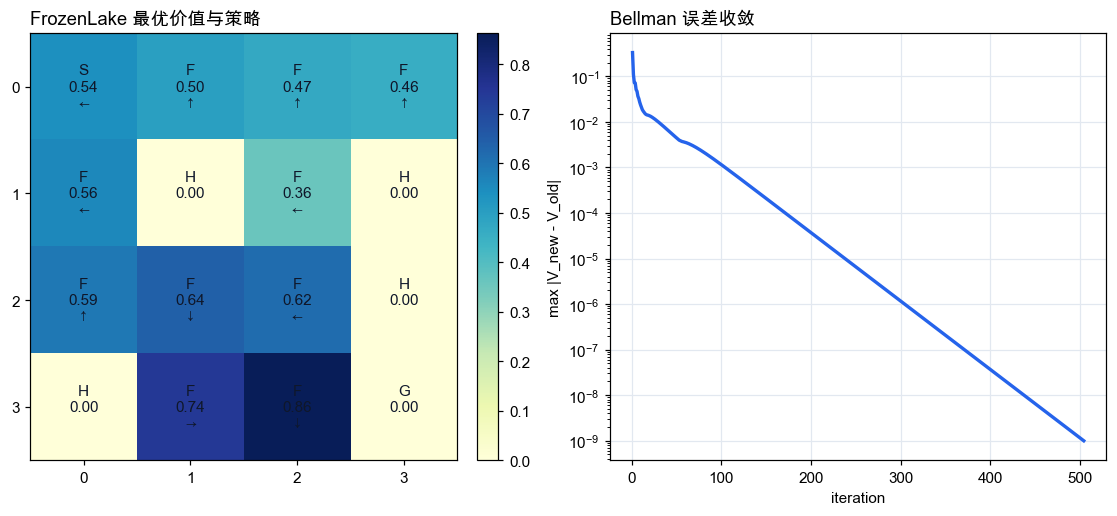

In [5]:
# 绘制 FrozenLake 的价值、洞、终点和最优动作。
value_grid = V_frozen.reshape(4, 4)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))
im = axes[0].imshow(value_grid, cmap="YlGnBu", vmin=0, vmax=value_grid.max())
for state in range(n_states):
    r, c = divmod(state, 4)
    tile = lake_map[r, c]
    arrow = "" if tile in {"H", "G"} else action_arrows[int(policy_frozen[state])]
    axes[0].text(c, r, f"{tile}\n{value_grid[r, c]:.2f}\n{arrow}", ha="center", va="center", color="#0f172a", fontweight="bold")
axes[0].set_title("FrozenLake 最优价值与策略", loc="left", fontweight="bold")
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].plot(delta_trace["iteration"], delta_trace["delta"], color="#2563eb", linewidth=2.2)
axes[1].set_yscale("log")
axes[1].set_title("Bellman 误差收敛", loc="left", fontweight="bold")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("max |V_new - V_old|")
axes[1].grid(True, color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()